In [1]:
# Import PyTorch and required submodules for neural network construction and optimization
import torch
from torch import nn, optim

# Import datasets and transformation utilities from torchvision
from torchvision import datasets, transforms

# Import matplotlib for visualization (later used to plot results)
import matplotlib.pyplot as plt

# Define a simple transformation: convert image data to PyTorch tensors
tensor_transform = transforms.ToTensor()

# Load the MNIST dataset (handwritten digits) from torchvision
# - root='./data' specifies the directory to store the dataset
# - train=True means we load the training subset
# - download=True ensures the dataset is downloaded if not already available
# - transform=tensor_transform converts the data to PyTorch tensors


dataset = datasets.MNIST(root="./data",
                         train=True,
                         download=True,
                         transform=tensor_transform)


# Create a DataLoader to efficiently handle batching and shuffling of the dataset
# - batch_size=32 indicates that 32 images are processed per training step
# - shuffle=True ensures random sampling order, crucial for effective training

loader = torch.utils.data.DataLoader(dataset=dataset,
                                     batch_size=32,
                                     shuffle=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 433kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.57MB/s]


In this step we are going to define our autoencoder .It consists of two key components:

The encoder compresses the input image into a lower-dimensional representation (latent space). It consists of three convolutional layers with ReLU activation reducing dimensionality step by step using MaxPooling layers and the final output is the compressed representation of the input image. This reduces the dimensionality of the data sequentially as given by:

28*28 = 784 ==> 128 ==> 64 ==> 36 ==> 18 ==> 9

The decoder reconstructs the original image from the compressed representation. It uses three transposed convolution layers to progressively upsample the data back to the original size. The dimensionality of the data is linearly increased to the original input size in order to reconstruct the input.

9 ==> 18 ==> 36 ==> 64 ==> 128 ==> 784 ==> 28*28 = 784

In [2]:
# Define the Autoencoder neural network class (inherits from PyTorch's nn.Module)
class AE(nn.Module):
    def __init__(self):
        # Initialize the superclass (nn.Module)
        super(AE, self).__init__()

        # Define the Encoder part of the network
        # Encoder reduces dimensionality from original input size (28*28 = 784 pixels)
        # down to a smaller latent representation (size = 9)
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),  # Input layer (784) → Hidden layer (128 neurons)
            nn.ReLU(),                # Non-linear activation
            nn.Linear(128, 64),       # Hidden layer (128 → 64 neurons)
            nn.ReLU(),                # Activation function
            nn.Linear(64, 36),        # Hidden layer (64 → 36 neurons)
            nn.ReLU(),                # Activation function
            nn.Linear(36, 18),        # Hidden layer (36 → 18 neurons)
            nn.ReLU(),                # Activation function
            nn.Linear(18, 9)          # Final encoder layer (18 → 9 neurons, compressed latent space)
        )

        # Define the Decoder part of the network
        # Decoder reconstructs original data from latent representation back to 784 pixels
        self.decoder = nn.Sequential(
            nn.Linear(9, 18),         # Latent layer (9 → 18 neurons)
            nn.ReLU(),                # Activation function
            nn.Linear(18, 36),        # Hidden layer (18 → 36 neurons)
            nn.ReLU(),                # Activation function
            nn.Linear(36, 64),        # Hidden layer (36 → 64 neurons)
            nn.ReLU(),                # Activation function
            nn.Linear(64, 128),       # Hidden layer (64 → 128 neurons)
            nn.ReLU(),                # Activation function
            nn.Linear(128, 28 * 28),  # Output layer reconstructs original input size (128 → 784 pixels)
            nn.Sigmoid()              # Sigmoid ensures outputs are between 0 and 1 (pixel intensity)
        )

    # Define the forward pass (how data flows through the network)
    def forward(self, x):
        encoded = self.encoder(x)  # Encode input to latent representation
        decoded = self.decoder(encoded)  # Decode latent representation back to original dimension
        return decoded  # Return the reconstructed output


Step 3: Initializing Model
Now we validate the model using the Mean Squared Error function and we use an Adam Optimizer with a learning rate of 0.1 and weight decay of 10^(-8)


In [4]:
# Instantiate the Autoencoder model
model = AE()

# Define the loss function: Mean Squared Error (MSE)
# This measures the reconstruction error between input and output
loss_function = nn.MSELoss()

# Set up the optimizer: Adam optimizer with learning rate and regularization
optimizer = optim.Adam(
    model.parameters(),   # Parameters to optimize (encoder and decoder weights)
    lr=1e-3,              # Learning rate: controls update step-size (0.001 is common choice)
    weight_decay=1e-8     # Weight decay adds slight regularization to avoid overfitting
)


Step 4: Train the model and Plot Training Loss
In this step the model undergoes training for 20 epochs using the Mean Squared Error (MSE) loss function and the Adam optimizer. The training process updates the model’s weights using backpropagation and optimization techniques. Loss values are recorded during each iteration and after training a loss plot is generated to assess the model’s performance over time.

Epoch 1/1, Loss: 0.040803


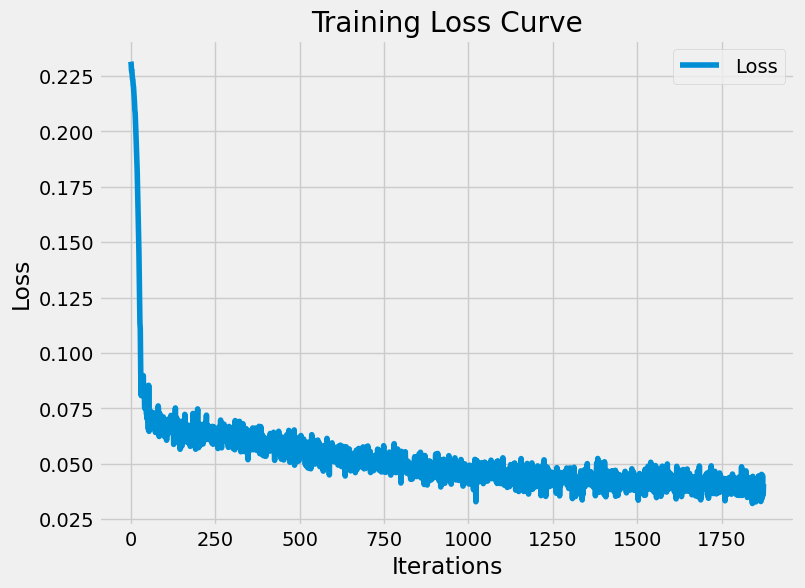

In [5]:
# Set number of training epochs
epochs =1 # 20  # number of passes through the entire training dataset (60k images)

# Lists to store outputs and losses during training for visualization
outputs = []
losses = []

# Check if GPU (CUDA) is available; use GPU if possible for faster computation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)  # Move the model to the selected device

# Training loop starts here
for epoch in range(epochs):
    # Iterate over data batches provided by DataLoader
    for batch_images, _ in loader:

        # Flatten images (from 28x28 pixels) to vectors (size: batch_size x 784)
        images = batch_images.view(-1, 28*28).to(device)

        # Forward pass: compute reconstructed images from autoencoder
        reconstructed = model(images)

        # Compute loss (difference between original and reconstructed images)
        loss = loss_function(reconstructed, images)

        # Backward pass: compute gradients
        optimizer.zero_grad()  # reset gradients from previous iteration
        loss.backward()        # backpropagate to compute gradients
        optimizer.step()       # update parameters based on gradients

        # Record loss value
        losses.append(loss.item())

    # After each epoch, store example output for visualization later
    outputs.append((epoch, images, reconstructed))

    # Print progress clearly
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

# After training, plot the training loss curve
plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 6))
plt.plot(losses, label='Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.show()


In [6]:
# Check if GPU (CUDA) is available; use GPU if possible for faster computation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)  # Move the model to the selected device

Step 5: Visualize Input and reconstructed Images
This step focuses on evaluating the performance of the trained autoencoder. By comparing the original MNIST images with their reconstructed versions we can assess how well the model has learned to encode and decode the data.

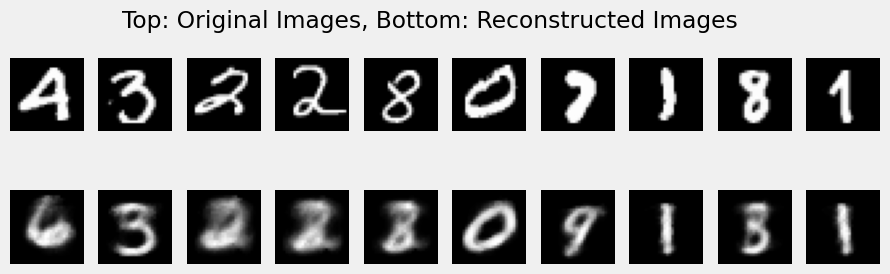

In [7]:
# Evaluate the trained autoencoder on a batch of images from MNIST dataset
model.eval()  # Switch the model to evaluation mode (turns off dropout, batchnorm, etc.)

# Obtain a batch of images from the DataLoader
images, _ = next(iter(loader))

# Flatten the images (batch_size × 784 pixels) and send to the computation device (CPU/GPU)
images = images.view(-1, 28 * 28).to(device)

# Pass images through the autoencoder to obtain reconstructed outputs
with torch.no_grad():  # Disable gradient calculation for evaluation
    reconstructed = model(images)

# Visualize original images (top row) and reconstructed images (bottom row)
fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(10, 3))

# Display original and reconstructed images side-by-side for comparison
for i in range(10):
    # Original images
    axes[0, i].imshow(images[i].cpu().numpy().reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    # Reconstructed images from the autoencoder
    axes[1, i].imshow(reconstructed[i].cpu().numpy().reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')

plt.suptitle('Top: Original Images, Bottom: Reconstructed Images')
plt.show()
